In [2]:

import os
import random
import shutil
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, models, transforms
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt
from itertools import cycle


os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
os.environ["TORCH_HOME"] = r"C:\Users\Külkedisi\Desktop\DLP Batch\torch_cache"
os.makedirs(os.environ["TORCH_HOME"], exist_ok=True)


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Cihaz: {device}")


DATA_DIR = r"C:\Users\Külkedisi\Desktop\DLP Batch\garbage-dataset"
BATCH_SIZE = 32
SEARCH_EPOCHS = 5
FULL_EPOCHS = 20
PATIENCE = 3
OUTPUT_DIR = r"C:\Users\Külkedisi\Desktop\DLP Batch"
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)


data_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

try:
    full_dataset = datasets.ImageFolder(DATA_DIR, transform=data_transforms)
    classes = full_dataset.classes
except:
    
    full_dataset = datasets.FakeData(size=50, image_size=(3,224,224), num_classes=2, transform=data_transforms)
    classes = ['class0','class1']


targets = full_dataset.targets
train_idx, temp_idx = train_test_split(range(len(full_dataset)), test_size=0.3, stratify=targets, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=[targets[i] for i in temp_idx], random_state=42)

train_loader = DataLoader(Subset(full_dataset, train_idx), batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(Subset(full_dataset, val_idx), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(Subset(full_dataset, test_idx), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

def get_efficientnet(num_classes, pretrained=True):
    weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None
    model = models.efficientnet_b0(weights=weights)
    
   
    for p in model.parameters():
        p.requires_grad = False
    
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, num_classes)
    )
    return model.to(device)

criterion = nn.CrossEntropyLoss()


mkdir -p failed for path C:\Users\Külkedisi\.matplotlib: [WinError 5] Access is denied: 'C:\\Users\\Külkedisi\\.matplotlib'
Matplotlib created a temporary cache directory at C:\Users\KLKEDI~1\AppData\Local\Temp\matplotlib-aneg0jwu because there was an issue with the default path (C:\Users\Külkedisi\.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Cihaz: cuda


In [8]:


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss, correct, total = 0,0,0
    for x,y in loader:
        x,y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out,y)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * x.size(0)
        _, pred = out.max(1)
        correct += pred.eq(y).sum().item()
        total += y.size(0)
    return running_loss/len(loader.dataset), 100.*correct/total

def validate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0,0,0
    all_probs, all_labels = [], []
    with torch.no_grad():
        for x,y in loader:
            x,y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out,y)
            running_loss += loss.item() * x.size(0)
            _, pred = out.max(1)
            correct += pred.eq(y).sum().item()
            total += y.size(0)
            all_probs.append(torch.softmax(out, dim=1).cpu())
            all_labels.append(y.cpu())
    
    all_probs = torch.cat(all_probs)
    all_labels = torch.cat(all_labels)

    try:
        if all_probs.shape[1]==2:
            roc = roc_auc_score(all_labels.numpy(), all_probs[:,1].numpy())
        else:
            y_true = label_binarize(all_labels.numpy(), classes=range(all_probs.shape[1]))
            roc = roc_auc_score(y_true, all_probs.numpy(), average='macro')
    except:
        roc = 0.0
    return running_loss/len(loader.dataset), correct/total, roc


lr_candidates = [10**np.random.uniform(-5,-2) for _ in range(5)]
best_lr = None
best_val_acc_search = 0.0

print("\n=== Random LR Search Başlıyor ===")
print("Denenecek LR'ler:", [f"{lr:.6f}" for lr in lr_candidates])

for i, lr in enumerate(lr_candidates):
    print(f"\n>>> Deneme {i+1}/5 | LR: {lr:.6f}")
    temp_model = get_efficientnet(len(classes))
    optimizer = optim.Adam(temp_model.parameters(), lr=lr)
    
    for epoch in range(SEARCH_EPOCHS):
        train_loss, train_acc = train_one_epoch(temp_model, train_loader, criterion, optimizer)
        val_loss, val_acc, val_roc = validate(temp_model, val_loader, criterion)
        print(f"   Ep {epoch+1}: Train Loss {train_loss:.3f} | Val Acc %{val_acc:.2f} | Val ROC {val_roc:.4f}")
    
    if val_acc > best_val_acc_search:
        best_val_acc_search = val_acc
        best_lr = lr
        print("   --> (!) Şu ana kadarki en iyi sonuç!")

print(f"\n>>> Kazanan LR: {best_lr:.6f}")


final_model = get_efficientnet(len(classes))
optimizer = optim.Adam(final_model.parameters(), lr=best_lr)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=FULL_EPOCHS)

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_roc': []}
best_val_acc = 0.0


def unfreeze_last_layers(model, n=2):

    for p in list(model.features[-n:].parameters()):
        p.requires_grad = True

unfreeze_last_layers(final_model, n=2)

for epoch in range(FULL_EPOCHS):
    train_loss, train_acc = train_one_epoch(final_model, train_loader, criterion, optimizer)
    val_loss, val_acc, val_roc = validate(final_model, val_loader, criterion)
    

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc/100.0)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc/100.0)
    history['val_roc'].append(val_roc)
    
  
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(final_model.state_dict(), os.path.join(OUTPUT_DIR,"best_model_efficientnet.pth"))
        print(f"✅ Epoch {epoch+1}: En iyi model kaydedildi! Val Acc %{val_acc:.2f}")
    
    print(f"Ep {epoch+1}/{FULL_EPOCHS} | Train Loss {train_loss:.3f} | Val Acc %{val_acc:.2f} | Val ROC {val_roc:.4f}")
    scheduler.step()


final_model.load_state_dict(torch.load(os.path.join(OUTPUT_DIR,"best_model_efficientnet.pth"), weights_only=True))
final_model.eval()
print("✅ Eğitim bitti, en iyi modeli yükledim.")





=== Random LR Search Başlıyor ===
Denenecek LR'ler: ['0.000133', '0.007114', '0.001570', '0.000625', '0.000029']

>>> Deneme 1/5 | LR: 0.000133


C:\Users\Külkedisi\AppData\Roaming\Python\Python310\site-packages\torch\nn\modules\module.py:1326: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\c10/cuda/CUDAAllocatorConfig.h:28.)
  return t.to(


   Ep 1: Train Loss 0.770 | Val Acc %0.91 | Val ROC 0.9926
   Ep 2: Train Loss 0.410 | Val Acc %0.92 | Val ROC 0.9941
   Ep 3: Train Loss 0.342 | Val Acc %0.93 | Val ROC 0.9951
   Ep 4: Train Loss 0.300 | Val Acc %0.94 | Val ROC 0.9958
   Ep 5: Train Loss 0.265 | Val Acc %0.93 | Val ROC 0.9956
   --> (!) Şu ana kadarki en iyi sonuç!

>>> Deneme 2/5 | LR: 0.007114
   Ep 1: Train Loss 0.581 | Val Acc %0.90 | Val ROC 0.9929
   Ep 2: Train Loss 0.388 | Val Acc %0.92 | Val ROC 0.9950
   Ep 3: Train Loss 0.326 | Val Acc %0.92 | Val ROC 0.9951
   Ep 4: Train Loss 0.302 | Val Acc %0.93 | Val ROC 0.9959
   Ep 5: Train Loss 0.264 | Val Acc %0.93 | Val ROC 0.9961

>>> Deneme 3/5 | LR: 0.001570
   Ep 1: Train Loss 0.494 | Val Acc %0.92 | Val ROC 0.9947
   Ep 2: Train Loss 0.344 | Val Acc %0.92 | Val ROC 0.9953
   Ep 3: Train Loss 0.285 | Val Acc %0.93 | Val ROC 0.9959
   Ep 4: Train Loss 0.256 | Val Acc %0.94 | Val ROC 0.9964
   Ep 5: Train Loss 0.230 | Val Acc %0.93 | Val ROC 0.9961
   --> (!) Şu

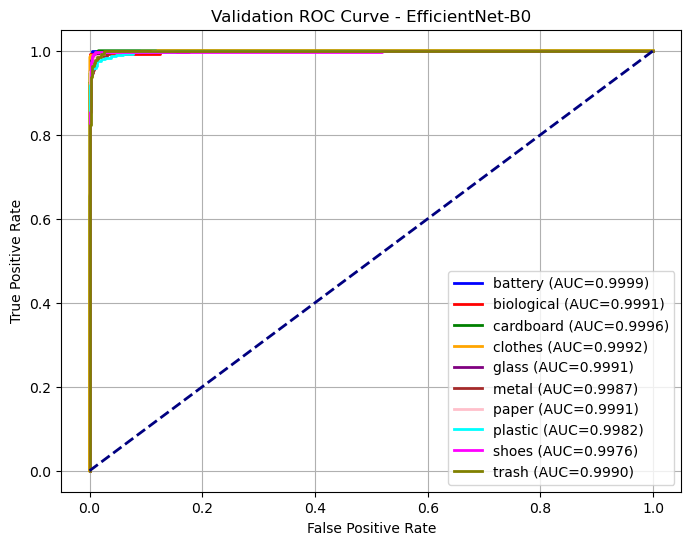

In [9]:

all_probs, all_labels = [], []
with torch.no_grad():
    for x, y in val_loader:
        x, y = x.to(device), y.to(device)
        out = final_model(x)
        all_probs.append(torch.softmax(out, dim=1).cpu())
        all_labels.append(y.cpu())

all_probs = torch.cat(all_probs)
all_labels = torch.cat(all_labels)

if all_probs.shape[1] == 2:
    # Binary classification
    fpr, tpr, _ = roc_curve(all_labels.numpy(), all_probs[:,1].numpy())
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(8,6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0,1],[0,1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Validation ROC Curve - EfficientNet-B0')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()
else:
    # Multi-class ROC
    y_true = label_binarize(all_labels.numpy(), classes=range(all_probs.shape[1]))
    fpr, tpr, roc_auc_dict = dict(), dict(), dict()
    colors = ['blue','red','green','orange','purple','brown','pink','cyan','magenta','olive']
    
    plt.figure(figsize=(8,6))
    for i, color in zip(range(all_probs.shape[1]), cycle(colors)):
        fpr[i], tpr[i], _ = roc_curve(y_true[:,i], all_probs[:,i].numpy())
        roc_auc_dict[i] = auc(fpr[i], tpr[i])
        plt.plot(fpr[i], tpr[i], color=color, lw=2, label=f'{classes[i]} (AUC={roc_auc_dict[i]:.4f})')
    
    plt.plot([0,1],[0,1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Validation ROC Curve - EfficientNet-B0')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()


C:\Users\Külkedisi\AppData\Local\Temp\ipykernel_12312\3832687092.py:41: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  final_model.load_state_dict(torch.load('best_model_effi

Accuracy: 0.9710
F1 Score (Macro): 0.9640
Cohen's Kappa: 0.9662


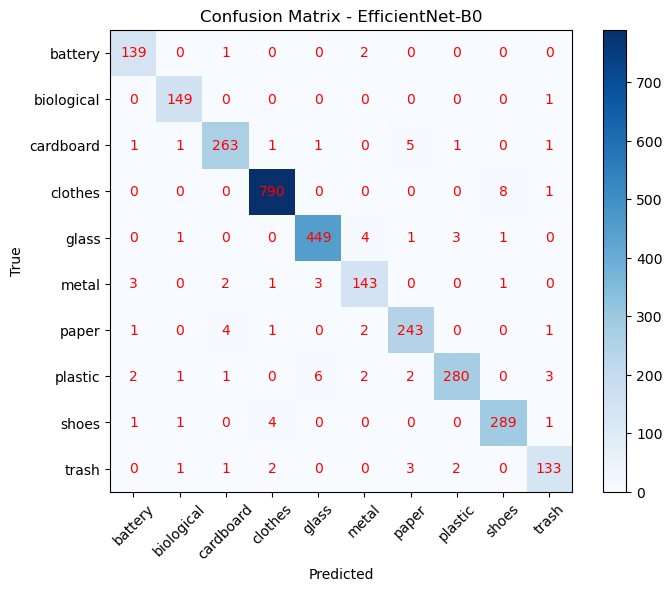

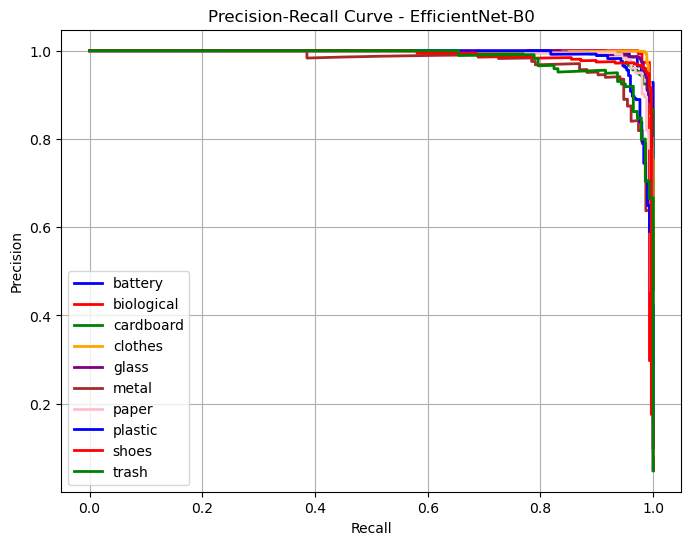

In [10]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, confusion_matrix, precision_recall_curve
from sklearn.preprocessing import label_binarize
from itertools import cycle
import random
from torchvision import models


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def get_efficientnet(num_classes, pretrained=True):
    weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None
    model = models.efficientnet_b0(weights=weights)

    for p in model.parameters():
        p.requires_grad = False
    
    in_ftrs = model.classifier[1].in_features
    model.classifier = torch.nn.Sequential(
        torch.nn.Linear(in_ftrs, 512),
        torch.nn.BatchNorm1d(512),
        torch.nn.ReLU(),
        torch.nn.Dropout(0.5),
        torch.nn.Linear(512, num_classes)
    )
    return model.to(device)


num_classes = len(classes)
final_model = get_efficientnet(num_classes, pretrained=False)
final_model.load_state_dict(torch.load('best_model_efficientnet.pth', map_location=device))
final_model.eval()


all_probs, all_labels, all_preds = [], [], []

with torch.no_grad():
    for x, y in val_loader:
        x, y = x.to(device), y.to(device)
        out = final_model(x)
        probs = torch.softmax(out, dim=1)
        all_probs.append(probs.cpu())
        all_labels.append(y.cpu())
        all_preds.append(probs.argmax(1).cpu())

all_probs = torch.cat(all_probs)
all_labels = torch.cat(all_labels)
all_preds = torch.cat(all_preds)

class_names = classes
colors = ['blue','red','green','orange','purple','brown','pink']


acc = accuracy_score(all_labels.numpy(), all_preds.numpy())
print(f"Accuracy: {acc:.4f}")


f1_scores = f1_score(all_labels.numpy(), all_preds.numpy(), average=None)
f1_macro = f1_score(all_labels.numpy(), all_preds.numpy(), average='macro')
print(f"F1 Score (Macro): {f1_macro:.4f}")



kappa = cohen_kappa_score(all_labels.numpy(), all_preds.numpy())
print(f"Cohen's Kappa: {kappa:.4f}")


cm = confusion_matrix(all_labels.numpy(), all_preds.numpy())
plt.figure(figsize=(8,6))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix - EfficientNet-B0')
plt.colorbar()
plt.xticks(range(num_classes), class_names, rotation=45)
plt.yticks(range(num_classes), class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.grid(False)
for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='red')
plt.show()


plt.figure(figsize=(8,6))
for i, color in zip(range(num_classes), cycle(colors)):
    precision, recall, _ = precision_recall_curve(
        label_binarize(all_labels.numpy(), classes=range(num_classes))[:, i],
        all_probs[:, i].numpy()
    )
    plt.plot(recall, precision, color=color, lw=2, label=f'{class_names[i]}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - EfficientNet-B0')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()



In [14]:
import torch
import numpy as np
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt


final_model.eval()

y_true = []
y_pred = []
y_prob = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        y = y.to(device)

        outputs = final_model(x)
        probs = torch.softmax(outputs, dim=1)

        y_true.extend(y.cpu().numpy())
        y_pred.extend(outputs.argmax(1).cpu().numpy())
        y_prob.extend(probs.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

print("✅ y_true, y_pred, y_prob hazır")


✅ y_true, y_pred, y_prob hazır


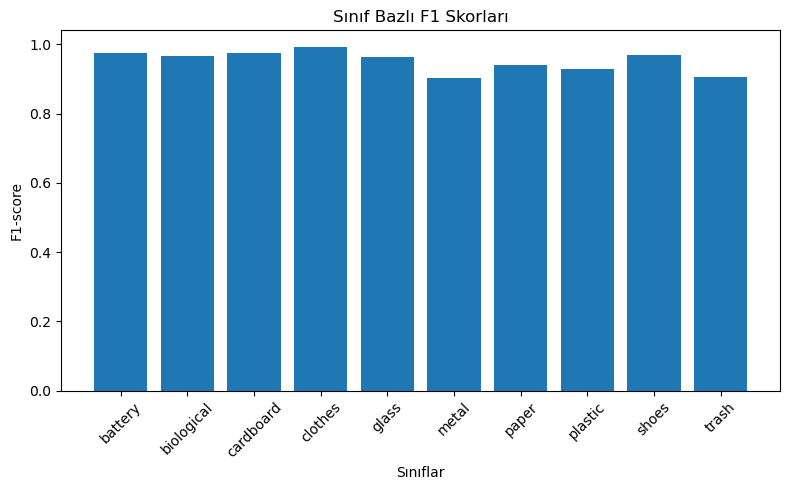

In [16]:
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import numpy as np
class_names = test_loader.dataset.dataset.classes

f1_scores = f1_score(y_true, y_pred, average=None)

plt.figure(figsize=(8,5))
plt.bar(class_names, f1_scores)
plt.xlabel("Sınıflar")
plt.ylabel("F1-score")
plt.title("Sınıf Bazlı F1 Skorları")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


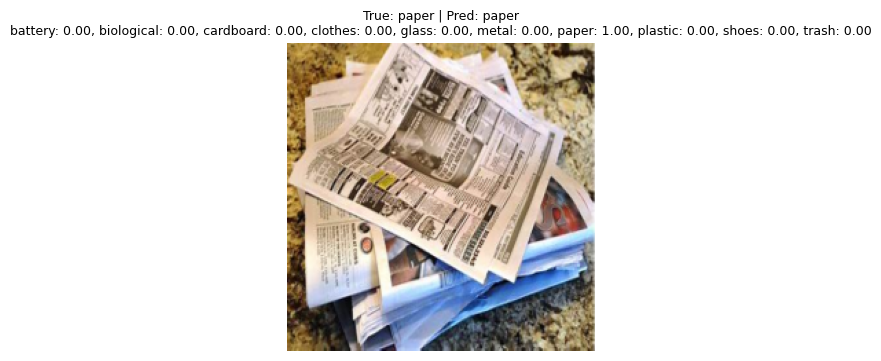

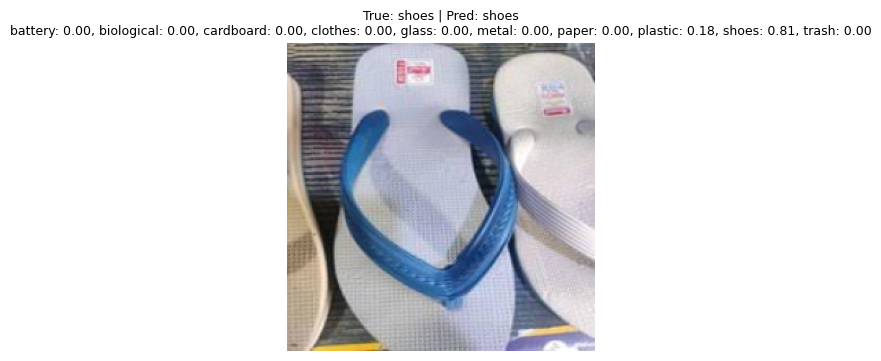

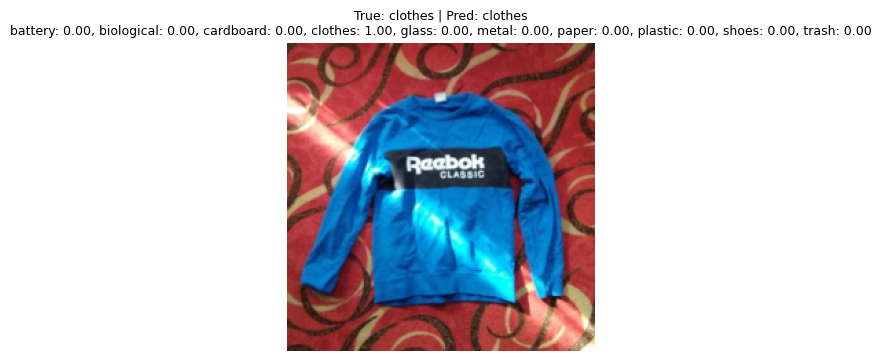

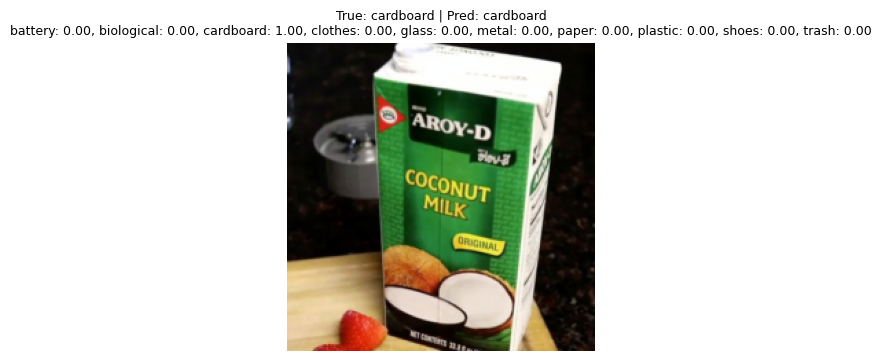

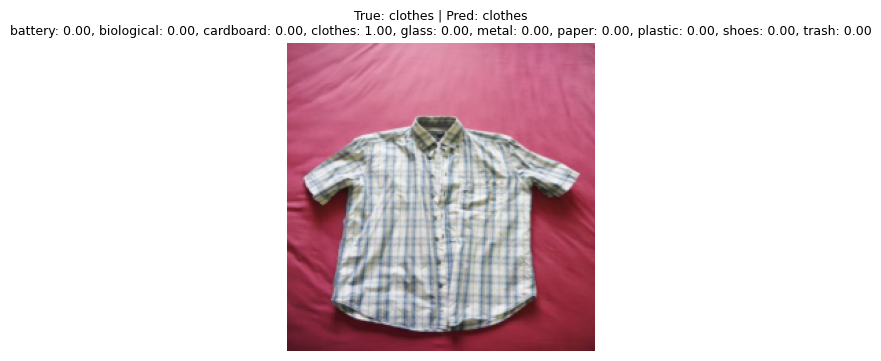

In [17]:

num_examples = 5
indices = random.sample(range(len(test_loader.dataset)), num_examples)

for idx in indices:
    img, label = test_loader.dataset[idx]
    
   
    img_display = img.permute(1,2,0).numpy()  
    img_display = img_display * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406])
    img_display = np.clip(img_display, 0, 1)
    
    
    final_model.eval()
    with torch.no_grad():
        x = img.unsqueeze(0).to(device)
        out = final_model(x)
        pred_class = class_names[out.argmax(1).item()]
        probs = torch.softmax(out, dim=1)[0]
  
    prob_str = ", ".join([f"{cls}: {p:.2f}" for cls,p in zip(class_names, probs.cpu().numpy())])
    
    plt.figure(figsize=(4,4))
    plt.imshow(img_display)
    plt.title(f'True: {class_names[label]} | Pred: {pred_class}\n{prob_str}', fontsize=9)
    plt.axis('off')
    plt.show()


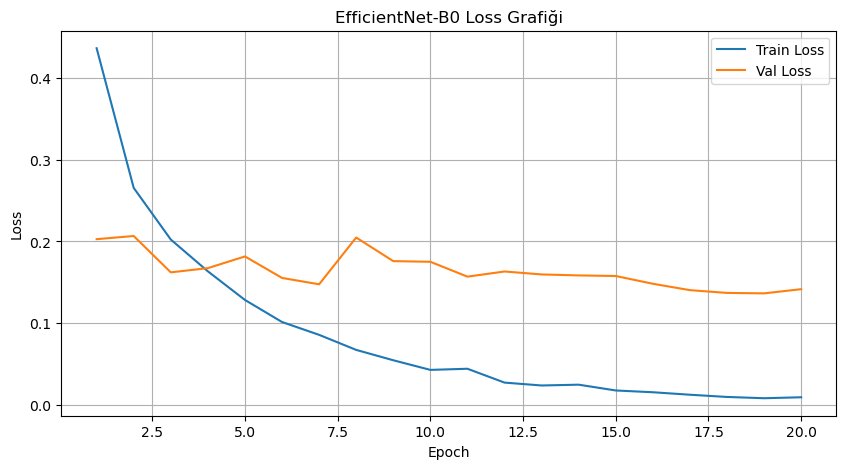

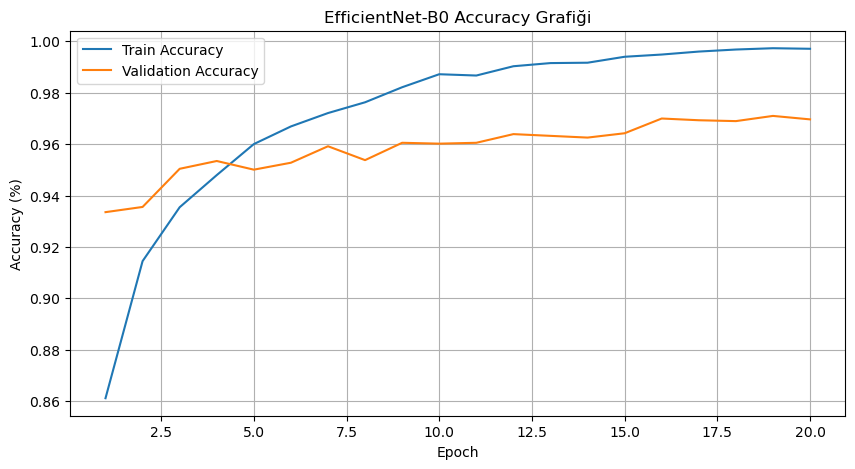

In [18]:

epochs = range(1, len(history['train_loss']) + 1)


plt.figure(figsize=(10,5))
plt.plot(epochs, history['train_loss'], label='Train Loss')
plt.plot(epochs, history['val_loss'], label='Val Loss')
plt.title("EfficientNet-B0 Loss Grafiği")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(10,5))
plt.plot(epochs, history['train_acc'], label='Train Accuracy')

val_acc_percent = [v*100 if v<=1 else v for v in history['val_acc']]
plt.plot(epochs, val_acc_percent, label='Validation Accuracy')
plt.title("EfficientNet-B0 Accuracy Grafiği")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)
plt.show()


In [7]:

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


DATA_DIR = r"C:\Users\Külkedisi\Desktop\DLP Batch\garbage-dataset"
BATCH_SIZE = 32

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

dataset = datasets.ImageFolder(DATA_DIR, transform=transform)
classes = dataset.classes
num_classes = len(classes)

test_loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


def get_efficientnet(num_classes):
    model = models.efficientnet_b0(weights=None)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, num_classes)
    )
    return model

model = get_efficientnet(num_classes).to(device)

model.load_state_dict(
    torch.load(
        r"C:\Users\Külkedisi\Desktop\DLP Batch\best_model_efficientnet.pth",
        map_location=device
    )
)

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

precision, recall, f1, support = precision_recall_fscore_support(
    all_labels,
    all_preds,
    average=None
)

class_accuracy = []
for i in range(num_classes):
    idx = np.where(np.array(all_labels) == i)
    acc = accuracy_score(
        np.array(all_labels)[idx],
        np.array(all_preds)[idx]
    )
    class_accuracy.append(acc)


results_df = pd.DataFrame({
    "Class": classes,
    "Accuracy": class_accuracy,
    "Precision": precision,
    "Recall": recall,
    "Macro F1": f1,
    "Support": support
})

results_df

C:\Users\Külkedisi\AppData\Local\Temp\ipykernel_13076\2146870797.py:58: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(


,Class,Accuracy,Precision,Recall,Macro F1,Support
0,battery,0.991525,0.989429,0.991525,0.990476,944
1,biological,0.995988,0.987078,0.995988,0.991513,997
2,cardboard,0.991233,0.990148,0.991233,0.990690,1825
3,clothes,0.996809,0.996622,0.996809,0.996715,5327
4,glass,0.991833,0.990862,0.991833,0.991347,3061
5,metal,0.979412,0.970845,0.979412,0.975110,1020
6,paper,0.982143,0.988024,0.982143,0.985075,1680
7,plastic,0.979335,0.987297,0.979335,0.983300,1984
8,shoes,0.990895,0.991397,0.990895,0.991146,1977
9,trash,0.976769,0.975738,0.976769,0.976253,947


In [12]:
import torch
import pandas as pd
import numpy as np
import os
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize


model_to_eval = get_efficientnet(len(classes)) 
model_path = os.path.join(OUTPUT_DIR, "best_model_efficientnet.pth")

try:
    model_to_eval.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    model_to_eval.to(device)
    model_to_eval.eval()
    print(f"✅ Model yüklendi: {model_path}")
except Exception as e:
    print(f"❌ Hata: {e}")


def get_standalone_summary(model, loader, num_classes):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            out = model(x)
            
            probs = torch.softmax(out, dim=1)
            preds = torch.argmax(out, dim=1)
            
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.numpy())

  
    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average="macro", zero_division=0)
    rec = recall_score(all_labels, all_preds, average="macro", zero_division=0)
    f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

   
    try:
        y_true_bin = label_binarize(all_labels, classes=range(num_classes))
        roc_auc = roc_auc_score(y_true_bin, np.array(all_probs), multi_class='ovr', average='macro')
    except:
        roc_auc = 0.0

    summary_df = pd.DataFrame({
        "Model": ["EfficientNet-B0 (Standalone)"],
        "Accuracy": [f"{acc:.4f}"],
        "Precision (Macro)": [f"{prec:.4f}"],
        "Recall (Macro)": [f"{rec:.4f}"],
        "F1-Score (Macro)": [f"{f1:.4f}"],
        "ROC-AUC": [f"{roc_auc:.4f}"]
    })
    
    return summary_df


final_results = get_standalone_summary(model_to_eval, test_loader, len(classes))

print("\n" + "="*65)
print("     🟢 EFFICIENTNET-B0 GENEL PERFORMANS TABLOSU")
print("="*65)
print(final_results.to_string(index=False))
print("="*65)

✅ Model yüklendi: C:\Users\Külkedisi\Desktop\DLP Batch\best_model_efficientnet.pth

     🟢 EFFICIENTNET-B0 GENEL PERFORMANS TABLOSU
                       Model Accuracy Precision (Macro) Recall (Macro) F1-Score (Macro) ROC-AUC
EfficientNet-B0 (Standalone)   0.9898            0.9867         0.9876           0.9872  0.9998
